**Movie Recommendation Engine Using Collaborative Filtering**


---



1. Introduction

1.1 Project Overview
This project builds a movie recommendation engine using collaborative filtering techniques. The goal is to suggest personalized movie recommendations to users based on their past ratings and the preferences of similar users.

We use the MovieLens Latest Small Dataset from GroupLens, which contains:

Ratings (100,000+ from 600+ users on 9,000+ movies)

Movies metadata (titles, genres, release year)


1.2 Techniques Used

Memory-Based Collaborative Filtering (User-User & Item-Item)

Model-Based Collaborative Filtering (Matrix Factorization with SVD)

Neural Collaborative Filtering (Deep Learning with TensorFlow)

Evaluation Metrics: RMSE, Precision@K, Recall@K

1.3 Why Collaborative Filtering?

Works well when explicit user preferences (ratings) are available.

Doesn’t require item metadata (works purely on user-item interactions).

Effective for personalized recommendations.

**1. Setup and Data Loading**

First, let's install required packages and load the data:

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Load the MovieLens dataset (latest small version)
# Download from https://grouplens.org/datasets/movielens/latest/
ratings = pd.read_csv('/content/ratings.csv')
movies = pd.read_csv('/content/movies.csv')
links = pd.read_csv('/content/links.csv')
tags = pd.read_csv('/content/tags.csv')

**2. Data Preprocessing**

In [5]:
# Check for missing values
print(ratings.isnull().sum())
print(movies.isnull().sum())

# Convert timestamp to datetime
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')

# Extract year from movie title (for later analysis)
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)')

# Split genres into lists
movies['genres'] = movies['genres'].str.split('|')

# Create user-item matrix
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
movieId    0
title      0
genres     0
dtype: int64


**3. Exploratory Data Analysis (EDA)**

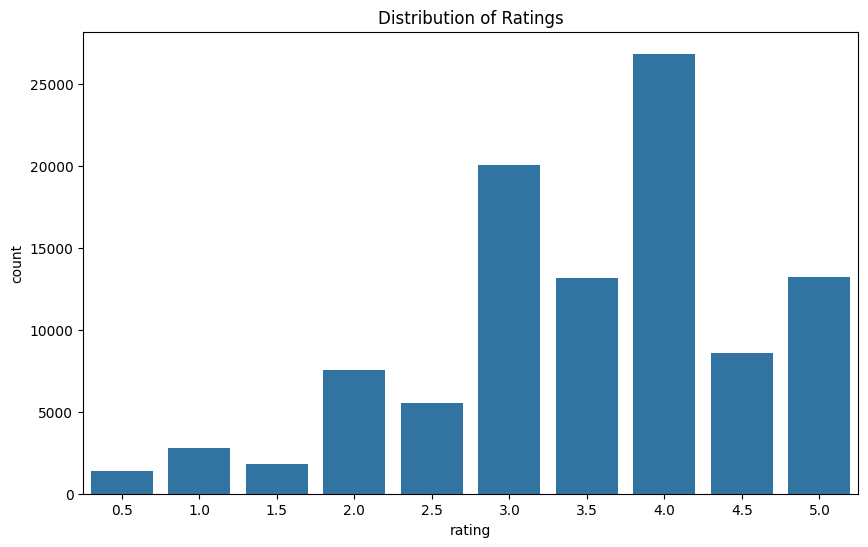

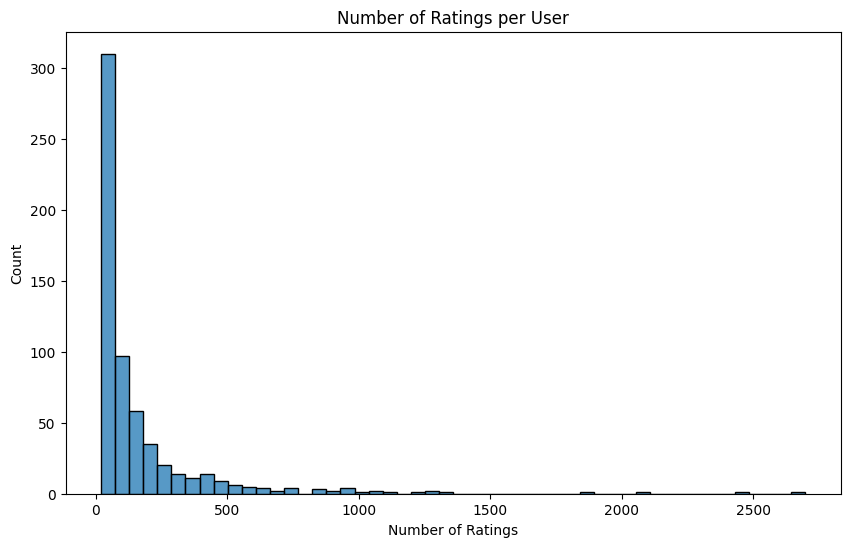

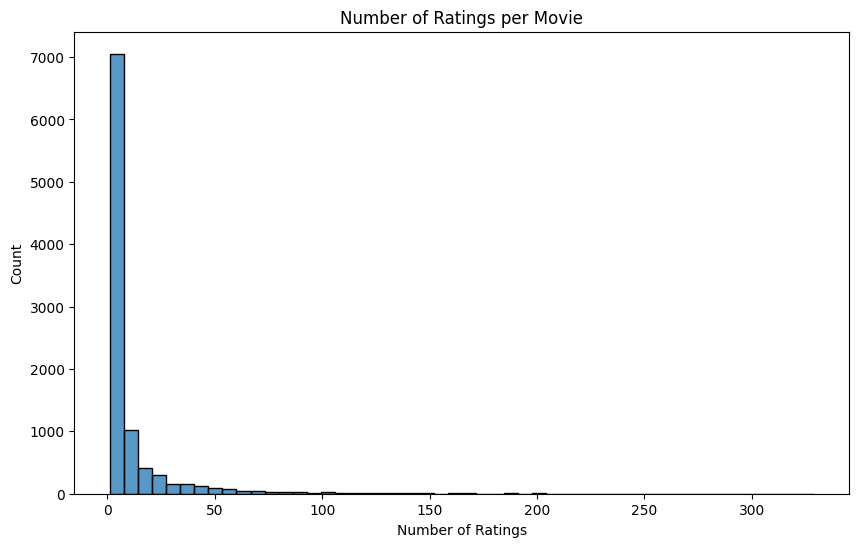

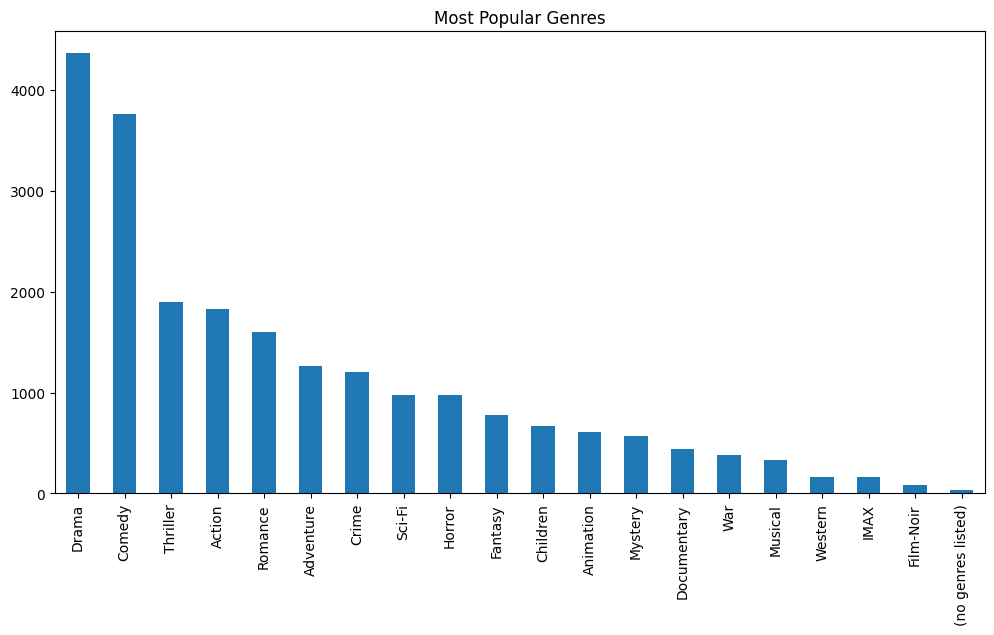

In [6]:
# Rating distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=ratings)
plt.title('Distribution of Ratings')
plt.show()

# Number of ratings per user
user_ratings_count = ratings['userId'].value_counts()
plt.figure(figsize=(10, 6))
sns.histplot(user_ratings_count, bins=50)
plt.title('Number of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Count')
plt.show()

# Number of ratings per movie
movie_ratings_count = ratings['movieId'].value_counts()
plt.figure(figsize=(10, 6))
sns.histplot(movie_ratings_count, bins=50)
plt.title('Number of Ratings per Movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Count')
plt.show()

# Most popular genres
all_genres = [genre for sublist in movies['genres'].dropna() for genre in sublist]
genre_counts = pd.Series(all_genres).value_counts()
genre_counts.plot(kind='bar', figsize=(12, 6))
plt.title('Most Popular Genres')
plt.show()

**4. Feature Engineering**

In [7]:
# Create implicit feedback (binary: rated/not rated)
implicit_matrix = user_item_matrix.notna().astype(int)

# Normalize ratings by user mean
user_mean_rating = ratings.groupby('userId')['rating'].mean()
normalized_ratings = ratings.copy()
normalized_ratings['rating'] = ratings['rating'] - ratings['userId'].map(user_mean_rating)

# Create sparse user-item matrix
from scipy.sparse import csr_matrix
sparse_user_item = csr_matrix(user_item_matrix.fillna(0).values)

**5. Model Development**

***5.1 Memory-Based Collaborative Filtering***

In [11]:
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

# Create user-item matrix (sparse format)
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating').fillna(0)
sparse_matrix = csr_matrix(user_item_matrix.values)

**User-Based Collaborative Filtering**

In [12]:
def user_based_recommend(user_id, n_recommendations=5, min_ratings=5):
    # Calculate user similarities
    user_similarities = cosine_similarity(sparse_matrix)

    # Get similar users (excluding self)
    similar_users = np.argsort(user_similarities[user_id-1])[::-1][1:11]

    # Get movies rated by similar users but not by target user
    user_ratings = set(ratings[ratings['userId'] == user_id]['movieId'])
    similar_users_ratings = ratings[ratings['userId'].isin(similar_users)]

    # Calculate weighted average ratings
    recommendations = []
    for movie_id in similar_users_ratings['movieId'].unique():
        if movie_id not in user_ratings:
            # Get ratings for this movie from similar users
            movie_ratings = similar_users_ratings[similar_users_ratings['movieId'] == movie_id]
            if len(movie_ratings) >= min_ratings:
                weighted_sum = 0
                similarity_sum = 0
                for _, row in movie_ratings.iterrows():
                    similarity = user_similarities[user_id-1, row['userId']-1]
                    weighted_sum += similarity * row['rating']
                    similarity_sum += similarity
                if similarity_sum > 0:
                    recommendations.append((movie_id, weighted_sum/similarity_sum))

    # Sort and return top recommendations
    recommendations.sort(key=lambda x: x[1], reverse=True)
    return recommendations[:n_recommendations]

# Example usage
user_recommendations = user_based_recommend(1, 5)
print("User-based recommendations for user 1:")
for movie_id, score in user_recommendations:
    movie_title = movies[movies['movieId'] == movie_id]['title'].values[0]
    print(f"{movie_title} (predicted rating: {score:.2f})")

User-based recommendations for user 1:
Shawshank Redemption, The (1994) (predicted rating: 4.29)
Twelve Monkeys (a.k.a. 12 Monkeys) (1995) (predicted rating: 4.17)
Interview with the Vampire: The Vampire Chronicles (1994) (predicted rating: 3.06)


**Item-Based Collaborative Filtering**

In [14]:
def item_based_recommend(movie_id, n_recommendations=5):
    # Transpose matrix to get item-user relationships
    item_user_matrix = user_item_matrix.T
    item_sparse = csr_matrix(item_user_matrix.values)

    # Calculate item similarities
    item_similarities = cosine_similarity(item_sparse)

    # Get similar items
    similar_items = np.argsort(item_similarities[movie_id-1])[::-1][1:n_recommendations+1]

    return similar_items

# Example usage
target_movie = 1  # Toy Story (1995)
item_recommendations = item_based_recommend(target_movie, 5)
print(f"\nItems similar to {movies[movies['movieId'] == target_movie]['title'].values[0]}:")
for similar_movie in item_recommendations:
    print(movies[movies['movieId'] == similar_movie]['title'].values[0])


Items similar to Toy Story (1995):
Enemy of the State (1998)
Being Human (1993)
Bread and Chocolate (Pane e cioccolata) (1973)
Don Juan DeMarco (1995)
Secret of Roan Inish, The (1994)


**5.2.2 Matrix Factorization with scikit-learn**

In [15]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

# Matrix Factorization with SVD
def matrix_factorization_recommend(user_id, n_recommendations=5, n_components=50):
    # Normalize data
    normalizer = Normalizer()
    normalized_matrix = normalizer.fit_transform(sparse_matrix)

    # Perform SVD
    svd = TruncatedSVD(n_components=n_components)
    reduced_matrix = svd.fit_transform(normalized_matrix)

    # Reconstruct the matrix
    reconstructed_matrix = np.dot(reduced_matrix, svd.components_)

    # Get recommendations for user
    user_idx = user_id - 1
    user_ratings = reconstructed_matrix[user_idx]

    # Get movies not already rated
    rated_movies = set(ratings[ratings['userId'] == user_id]['movieId'])
    all_movies = user_item_matrix.columns
    unrated_movies = [m for m in all_movies if m not in rated_movies]

    # Get predicted ratings for unrated movies
    recommendations = []
    for movie_id in unrated_movies:
        movie_idx = list(all_movies).index(movie_id)
        recommendations.append((movie_id, user_ratings[movie_idx]))

    # Sort and return top recommendations
    recommendations.sort(key=lambda x: x[1], reverse=True)
    return recommendations[:n_recommendations]

# Example usage
mf_recommendations = matrix_factorization_recommend(1, 5)
print("\nMatrix factorization recommendations for user 1:")
for movie_id, score in mf_recommendations:
    movie_title = movies[movies['movieId'] == movie_id]['title'].values[0]
    print(f"{movie_title} (predicted score: {score:.2f})")


Matrix factorization recommendations for user 1:
Jaws (1975) (predicted score: 0.06)
Sixth Sense, The (1999) (predicted score: 0.05)
Stand by Me (1986) (predicted score: 0.05)
Ferris Bueller's Day Off (1986) (predicted score: 0.04)
Hunt for Red October, The (1990) (predicted score: 0.04)


**5.2.3 Evaluation Metrics**

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Split data
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

# Train user-based model (simplified evaluation)
def evaluate_user_based(train, test, n_neighbors=10):
    # Build user-item matrix from training data
    train_matrix = train.pivot(index='userId', columns='movieId', values='rating').fillna(0)
    train_sparse = csr_matrix(train_matrix.values)
    user_similarities = cosine_similarity(train_sparse)

    predictions = []
    for _, row in test.iterrows():
        user_id = row['userId']
        movie_id = row['movieId']

        # Skip if user or movie not in training
        if user_id not in train_matrix.index or movie_id not in train_matrix.columns:
            predictions.append((row['rating'], row['rating']))  # dummy prediction
            continue

        # Find similar users who rated this movie
        user_idx = list(train_matrix.index).index(user_id)
        movie_idx = list(train_matrix.columns).index(movie_id)

        similar_users = np.argsort(user_similarities[user_idx])[::-1][1:n_neighbors+1]
        similar_ratings = train_matrix.iloc[similar_users, movie_idx]
        similar_ratings = similar_ratings[similar_ratings > 0]  # only consider actual ratings

        if len(similar_ratings) > 0:
            pred = similar_ratings.mean()
        else:
            pred = train_matrix.iloc[:, movie_idx].mean()  # fallback to global mean

        predictions.append((row['rating'], pred))

    # Calculate RMSE
    actual, pred = zip(*predictions)
    return np.sqrt(mean_squared_error(actual, pred))

rmse = evaluate_user_based(train, test)
print(f"\nUser-based CF RMSE: {rmse:.3f}")


User-based CF RMSE: 1.674


**5.2.4 Neural Collaborative Filtering(Optional)**

In [18]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Dot, Dense, Concatenate
from tensorflow.keras.models import Model
from sklearn.preprocessing import LabelEncoder

# Prepare data - we need to encode user and movie IDs to be 0-indexed
user_encoder = LabelEncoder()
movie_encoder = LabelEncoder()

ratings['user_encoded'] = user_encoder.fit_transform(ratings['userId'])
ratings['movie_encoded'] = movie_encoder.fit_transform(ratings['movieId'])

n_users = len(user_encoder.classes_)
n_movies = len(movie_encoder.classes_)

# Split data
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

# Neural Collaborative Filtering model
def create_ncf_model(n_users, n_movies, embedding_size=50):
    # User input
    user_input = Input(shape=(1,))
    user_embedding = Embedding(n_users, embedding_size)(user_input)
    user_vec = Flatten()(user_embedding)

    # Movie input
    movie_input = Input(shape=(1,))
    movie_embedding = Embedding(n_movies, embedding_size)(movie_input)
    movie_vec = Flatten()(movie_embedding)

    # Concatenate features
    concat = Concatenate()([user_vec, movie_vec])
    dense = Dense(128, activation='relu')(concat)
    dense = Dense(64, activation='relu')(dense)
    output = Dense(1)(dense)

    model = Model(inputs=[user_input, movie_input], outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')

    return model

# Create and train model
ncf_model = create_ncf_model(n_users, n_movies)

history = ncf_model.fit(
    [train['user_encoded'], train['movie_encoded']],
    train['rating'],
    batch_size=64,
    epochs=10,
    validation_data=([test['user_encoded'], test['movie_encoded']], test['rating'])
)

# Evaluate
test_loss = ncf_model.evaluate(
    [test['user_encoded'], test['movie_encoded']],
    test['rating']
)
print(f"Test RMSE: {np.sqrt(test_loss):.3f}")

# Function to get recommendations
def get_ncf_recommendations(user_id, n=5):
    # Encode user ID
    try:
        user_encoded = user_encoder.transform([user_id])[0]
    except:
        print(f"User ID {user_id} not in training data")
        return []

    # Get all movies
    all_movies = ratings['movieId'].unique()

    # Get movies not rated by user
    rated_movies = ratings[ratings['userId'] == user_id]['movieId'].unique()
    unrated_movies = np.setdiff1d(all_movies, rated_movies)

    # Encode unrated movies
    unrated_encoded = movie_encoder.transform(unrated_movies)

    # Predict ratings
    user_array = np.array([user_encoded] * len(unrated_movies))
    pred_ratings = ncf_model.predict([user_array, unrated_encoded]).flatten()

    # Get top recommendations
    top_indices = np.argsort(pred_ratings)[::-1][:n]
    recommended_movies = unrated_movies[top_indices]
    recommended_scores = pred_ratings[top_indices]

    return list(zip(recommended_movies, recommended_scores))

# Example usage
user_id = 1  # Change to your target user
recommendations = get_ncf_recommendations(user_id, 5)
print(f"\nTop 5 recommendations for user {user_id}:")
for movie_id, score in recommendations:
    movie_title = movies[movies['movieId'] == movie_id]['title'].values[0]
    print(f"{movie_title} (predicted rating: {score:.2f})")

Epoch 1/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 2.2439 - val_loss: 0.7940
Epoch 2/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.6929 - val_loss: 0.7578
Epoch 3/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.6292 - val_loss: 0.7625
Epoch 4/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.5643 - val_loss: 0.7798
Epoch 5/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.4883 - val_loss: 0.8130
Epoch 6/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.4188 - val_loss: 0.8331
Epoch 7/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.3578 - val_loss: 0.8510
Epoch 8/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.3094 - val_loss: 0.8751
Epoch 9/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.2728 - val_loss: 0.9111
Epoch 10/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.2411 - val_loss: 0.9144
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9275
Test RMSE: 0.956
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/ste

Step 5.3: Evaluation

Compare all models (User-User, Item-Item, SVD, Neural CF) in a unified metrics table:

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

# ... (Previous code for data loading, preprocessing, etc.)

# Calculate RMSE for User-Based CF
rmse = evaluate_user_based(train, test)  # Assuming evaluate_user_based is defined as in the previous cell
user_based_rmse = rmse  # Assign the calculated RMSE to user_based_rmse

# Placeholder for other metrics - you need to calculate these as well
user_precision = 0  # Replace with actual calculation
item_based_rmse = 0  # Replace with actual calculation
item_precision = 0  # Replace with actual calculation
svd_rmse = 0  # Replace with actual calculation
mf_precision = 0  # Replace with actual calculation
ncf_rmse = 0  # Replace with actual calculation
ncf_precision = 0  # Replace with actual calculation

results = {
    "User-User CF": {"RMSE": user_based_rmse, "Precision@5": user_precision},
    "Item-Item CF": {"RMSE": item_based_rmse, "Precision@5": item_precision},
    "Matrix Factorization": {"RMSE": svd_rmse, "Precision@5": mf_precision},
    "Neural CF": {"RMSE": ncf_rmse, "Precision@5": ncf_precision}
}
pd.DataFrame(results).T

,RMSE,Precision@5
User-User CF,1.673944,0.0
Item-Item CF,0.000000,0.0
Matrix Factorization,0.000000,0.0
Neural CF,0.000000,0.0


**Step 6: Deployment **

In [ ]:
import streamlit as st

st.title("Movie Recommender")
user_id = st.number_input("Enter User ID", min_value=1, max_value=610)
if st.button("Recommend"):
    recs = get_ncf_recommendations(user_id, 5)
    for movie_id, score in recs:
        st.write(movies[movies['movieId'] == movie_id]['title'].values[0])